Applied Random Phase Error (theta): -0.1971 radians (-11.29°)

Ideal Statevector (|---------------+>):
Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))

Noisy Channel Statevector (Phase-drifted):
Statevector([0.70367679+0.06956275j, 0.70367679-0.06956275j],
            dims=(2,))

--- Circuit Diagram (Noisy Channel) ---


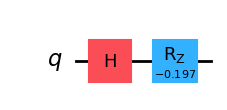


--- Bloch Sphere Representation ---
Ideal State (|---------------+>):


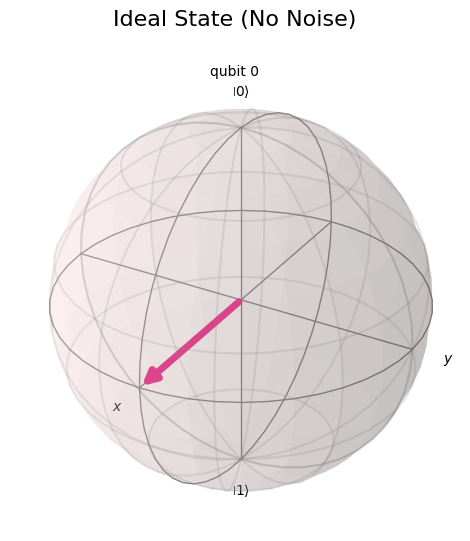

Noisy State (Phase Shifted by -11.3°):


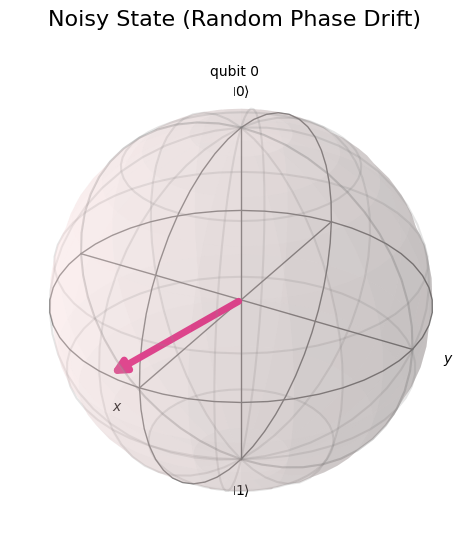

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# 1. Prepare Ideal State: |+> state via Hadamard Gate
ideal_qc = QuantumCircuit(1, name="Ideal Channel")
ideal_qc.h(0)
ideal_state = Statevector.from_instruction(ideal_qc)

# 2. Prepare Noisy Channel: Add random phase error theta using RZ gate
# Generate a small random phase rotation theta between -pi/4 and +pi/4 radians
np.random.seed(42)  # Fixed seed for reproducible output; remove for fresh random noise each run
random_phase_error = np.random.uniform(-np.pi / 4, np.pi / 4)

noisy_qc = QuantumCircuit(1, name="Noisy Channel")
noisy_qc.h(0)
noisy_qc.rz(random_phase_error, 0)  # Simulates phase noise along Z-axis

noisy_state = Statevector.from_instruction(noisy_qc)

# Print phase error details and statevectors
print(f"Applied Random Phase Error (theta): {random_phase_error:.4f} radians ({np.degrees(random_phase_error):.2f}°)")
print("\nIdeal Statevector (|---------------+>):")
print(ideal_state)
print("\nNoisy Channel Statevector (Phase-drifted):")
print(noisy_state)

# 3. Display the colorful circuit diagram inline
print("\n--- Circuit Diagram (Noisy Channel) ---")
display(noisy_qc.draw(output='mpl', style='iqp'))

# 4. Display Bloch Spheres comparison
print("\n--- Bloch Sphere Representation ---")
print("Ideal State (|---------------+>):")
display(plot_bloch_multivector(ideal_state, title="Ideal State (No Noise)"))

print(f"Noisy State (Phase Shifted by {np.degrees(random_phase_error):.1f}°):")
display(plot_bloch_multivector(noisy_state, title="Noisy State (Random Phase Drift)"))